# pymicromegas Demo

This notebook demonstrates a real relic density calculation with the bundled micrOMEGAs 5.0.8 source tree and the `SingletDM` sample model. It checks both the standard `Project` execution path and the `ctypes`-based `MicrOmegas` execution path.


## 1. Check the execution environment and dependencies

Check Python, the OS, and basic commands such as `make` and a C compiler, which are needed to build and run micrOMEGAs.


In [1]:
from __future__ import annotations

import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = Path("/Users/gomeshun/workspace/pymicromegas")

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def run_command(command, cwd=None, check=False):
    return subprocess.run(
        command,
        cwd=cwd,
        shell=isinstance(command, str),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=check,
    )


def first_line(text):
    lines = (text or "").splitlines()
    return lines[0] if lines else ""


env_df = pd.DataFrame(
    [
        {"item": "Python", "value": sys.version.split()[0]},
        {"item": "Executable", "value": sys.executable},
        {"item": "Platform", "value": platform.platform()},
        {"item": "Repository", "value": str(REPO_ROOT)},
    ]
)

tool_rows = []
for name in ["make", "cc", "gcc", "clang", "curl", "wget"]:
    path = shutil.which(name)
    version = ""
    if path:
        probe = run_command([path, "--version"])
        version = first_line(probe.stdout) or first_line(probe.stderr)
    tool_rows.append(
        {
            "command": name,
            "available": bool(path),
            "path": path or "",
            "version": version,
        }
    )

display(env_df)
display(pd.DataFrame(tool_rows))

,item,value
0,Python,3.14.0b4
1,Executable,/Users/gomeshun/workspace/pymicromegas/.venv/b...
2,Platform,macOS-26.5-arm64-arm-64bit-Mach-O
3,Repository,/Users/gomeshun/workspace/pymicromegas


,command,available,path,version
0,make,True,/usr/bin/make,GNU Make 3.81
1,cc,True,/usr/bin/cc,Apple clang version 12.0.5 (clang-1205.0.22.9)
2,gcc,True,/usr/bin/gcc,Apple clang version 12.0.5 (clang-1205.0.22.9)
3,clang,True,/usr/bin/clang,Apple clang version 12.0.5 (clang-1205.0.22.9)
4,curl,True,/usr/bin/curl,curl 8.7.1 (x86_64-apple-darwin25.0) libcurl/8...
5,wget,False,,


## 2. Locate the micrOMEGAs source

`pymicromegas` bundles micrOMEGAs 5.0.8 as package data. This demo uses the bundled source tree as the already available distribution instead of downloading it from the network.


In [2]:
from pymicromegas import MicrOmegas, Project, PyMicrOmegas

OFFICIAL_SOURCE_NOTE = (
    "micrOMEGAs 5.0.8 bundled under src/pymicromegas/micromegas_5.0.8"
)
interface = PyMicrOmegas()
micromegas_dir = Path(interface.path).resolve()

source_df = pd.DataFrame(
    [
        {"item": "source", "value": OFFICIAL_SOURCE_NOTE},
        {"item": "path", "value": str(micromegas_dir)},
        {"item": "exists", "value": micromegas_dir.is_dir()},
        {"item": "already built", "value": interface.is_micromegas_built()},
    ]
)

display(source_df)
if not micromegas_dir.is_dir():
    raise FileNotFoundError(f"micrOMEGAs source tree is missing: {micromegas_dir}")

,item,value
0,source,micrOMEGAs 5.0.8 bundled under src/pymicromega...
1,path,/Users/gomeshun/workspace/pymicromegas/src/pym...
2,exists,True
3,already built,True


## 3. Build the sample model

Place `pymicromegas_main.c` in the bundled `SingletDM` model and build the demo executable through micrOMEGAs `make`.


In [3]:
MODEL_NAME = "SingletDM"
PARAMETERS = {
    "Q": 100.0,
    "Mh": 125.0,
    "laS": 0.2,
    "laSH": 0.1,
    "Mdm1": 50.0,
}

project = Project(MODEL_NAME)
compile_process = project.compile()

print(f"model: {MODEL_NAME}")
print(f"project directory: {project.path}")
print(f"return code: {compile_process.returncode}")
print("\n--- stdout ---")
print((compile_process.stdout or "").strip()[-4000:] or "(no stdout)")
if compile_process.stderr:
    print("\n--- stderr ---")
    print(compile_process.stderr.strip()[-4000:])

make main=pymicromegas_main.c
model: SingletDM
project directory: /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_5.0.8/SingletDM/
return code: 0

--- stdout ---
/Library/Developer/CommandLineTools/usr/bin/make -C work
make[1]: Nothing to be done for `all'.
/Library/Developer/CommandLineTools/usr/bin/make -C lib
make[1]: Nothing to be done for `all'.
/Library/Developer/CommandLineTools/usr/bin/make -C ../sources
make[1]: Nothing to be done for `all'.
clang  -g -fsigned-char -std=gnu99 -Wno-error=implicit-function-declaration -Wno-implicit-function-declaration -o pymicromegas_main pymicromegas_main.c  lib/aLib.a ../lib/micromegas.a  /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_5.0.8/CalcHEP_src/lib/dynamic_me.a ../lib/micromegas.a work/work_aux.a  lib/aLib.a   /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_5.0.8/CalcHEP_src/lib/sqme_aux.so /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_5.0.8/CalcHEP_src/lib

## 4. Run the demo executable

Run the built `pymicromegas_main` executable through `subprocess` and inspect the raw micrOMEGAs standard output.


In [4]:
run_process = project.run(PARAMETERS, flags=["OMEGA"])

print(f"return code: {run_process.returncode}")
print("\n--- stdout ---")
print(run_process.stdout)
if run_process.stderr:
    print("\n--- stderr ---")
    print(run_process.stderr)

return code: 0

--- stdout ---

Dark matter candidate is '~x1' with spin=0/2 mass=5.00E+01

==== Calculation of relic density =====
Xf=2.38e+01 Omega=4.62e-02
# Channels which contribute to 1/(omega) more than 1%.
# Relative contributions in % are displayed
   81% ~x1 ~x1 ->b B 
    8% ~x1 ~x1 ->l L 
    7% ~x1 ~x1 ->G G 
    3% ~x1 ~x1 ->c C 



## 5. Load and verify the output

Extract the relic density, freeze-out parameter, and contributing annihilation channels as Python objects. Then compute the same parameter point with the `ctypes`-based `MicrOmegas` class.


In [6]:
omega_result = project.parse_omega(run_process.stdout, ["OMEGA"], with_channels=True)
summary = {key: value for key, value in omega_result.items() if key != "channels"}
channels = omega_result.get("channels", [])

summary_df = pd.DataFrame([{**PARAMETERS, **summary}])
channels_df = pd.DataFrame(channels)
if not channels_df.empty:
    channels_df["Br_percent"] = channels_df["Br"].str.rstrip("%").astype(float)
    channels_df = channels_df.sort_values("Br_percent", ascending=False).reset_index(
        drop=True
    )

ctypes_model = MicrOmegas(MODEL_NAME)
ctypes_result = ctypes_model.dark_omega(PARAMETERS)
comparison_df = pd.DataFrame(
    [
        {"method": "Project.run + parse_omega", **summary},
        {"method": "MicrOmegas.dark_omega", **ctypes_result},
    ]
)

display(summary_df)
display(
    channels_df.head(10)
    if not channels_df.empty
    else pd.DataFrame([{"message": "no channels parsed"}])
)
display(comparison_df)

,Q,Mh,laS,laSH,Mdm1,Xf,Omega
0,100.0,125.0,0.2,0.1,50.0,23.8,0.0462


,Br,in,out,Br_percent
0,81%,"(~x1, ~x1)","(b, B)",81.0
1,8%,"(~x1, ~x1)","(l, L)",8.0
2,7%,"(~x1, ~x1)","(G, G)",7.0
3,3%,"(~x1, ~x1)","(c, C)",3.0


,method,Xf,Omega,err
0,Project.run + parse_omega,23.800000,0.046200,NaN
1,MicrOmegas.dark_omega,23.827296,0.046167,0.0


## 6. Change parameters and rerun

Vary `Mdm1` over several values and recalculate the relic density at each point.


In [7]:
scan_rows = []
for mdm1 in [45.0, 50.0, 55.0, 60.0, 65.0]:
    point = {**PARAMETERS, "Mdm1": mdm1}
    result = project.calc_omega(point)
    scan_rows.append(
        {
            "Mdm1": mdm1,
            "Omega": result["Omega"],
            "Xf": result["Xf"],
            "channels": len(result.get("channels", [])),
        }
    )

scan_df = pd.DataFrame(scan_rows)
display(scan_df)

,Mdm1,Omega,Xf,channels
0,45.0,0.090500,22.7,4
1,50.0,0.046200,23.8,4
2,55.0,0.005760,27.0,4
3,60.0,0.000047,31.7,5
4,65.0,0.005410,25.6,4


## 7. Visualize the results

Plot how the relic density changes as a function of `Mdm1`.


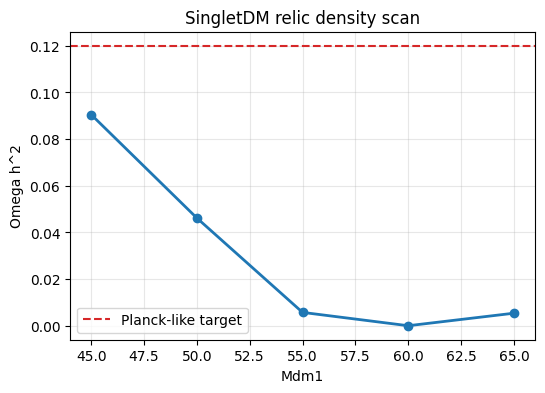

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scan_df["Mdm1"], scan_df["Omega"], marker="o", linewidth=2)
ax.axhline(
    0.12, color="tab:red", linestyle="--", linewidth=1.5, label="Planck-like target"
)
ax.set_xlabel("Mdm1")
ax.set_ylabel("Omega h^2")
ax.set_title("SingletDM relic density scan")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()